In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPUs detected:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.0
GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# CELL 1
import os

# This line MUST be executed before TensorFlow is imported for the first time.
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

# Now, this check will correctly show that no GPUs are visible.
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Import Libraries

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit,GridSearchCV
from keras.models import Sequential
from keras.layers import Input,Conv1D,ReLU,BatchNormalization,LSTM,Dropout,GlobalAveragePooling1D,Dense,LeakyReLU
from keras.optimizers import Adam,RMSprop
from keras.callbacks import  EarlyStopping, ReduceLROnPlateau
from scikeras.wrappers import KerasRegressor
from sklearn.metrics import mean_squared_error
from keras import regularizers
import keras_tuner as kt

# Import Data

In [4]:
Train_Data = np.genfromtxt('train_FD001.txt')
Test_Data = np.genfromtxt('test_FD001.txt')
RUL_Test_Data = np.genfromtxt('RUL_FD001.txt')

columns_names = ['unit_number','time_in_cycles', 'op_set_1','op_set_2','op_set_3','sensor_1','sensor_2','sensor_3',
                 'sensor_4','sensor_5','sensor_6','sensor_7','sensor_8','sensor_9','sensor_10','sensor_11','sensor_12',
                 'sensor_13','sensor_14','sensor_15','sensor_16','sensor_17','sensor_18','sensor_19','sensor_20','sensor_21']

df_Train_Data = pd.DataFrame(Train_Data, columns=columns_names)
df_Test_Data = pd.DataFrame(Test_Data, columns=columns_names)
df_RUL_Test_Data = pd.Series(RUL_Test_Data)

In [5]:
df_Train_Data

,unit_number,time_in_cycles,op_set_1,op_set_2,op_set_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1.0,1.0,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392.0,2388.0,100.0,39.06,23.4190
1,1.0,2.0,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392.0,2388.0,100.0,39.00,23.4236
2,1.0,3.0,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390.0,2388.0,100.0,38.95,23.3442
3,1.0,4.0,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392.0,2388.0,100.0,38.88,23.3739
4,1.0,5.0,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393.0,2388.0,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100.0,196.0,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397.0,2388.0,100.0,38.49,22.9735
20627,100.0,197.0,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395.0,2388.0,100.0,38.30,23.1594
20628,100.0,198.0,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398.0,2388.0,100.0,38.44,22.9333
20629,100.0,199.0,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395.0,2388.0,100.0,38.29,23.0640


In [6]:
df_Test_Data

,unit_number,time_in_cycles,op_set_1,op_set_2,op_set_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1.0,1.0,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392.0,2388.0,100.0,38.86,23.3735
1,1.0,2.0,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393.0,2388.0,100.0,39.02,23.3916
2,1.0,3.0,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393.0,2388.0,100.0,39.08,23.4166
3,1.0,4.0,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391.0,2388.0,100.0,39.00,23.3737
4,1.0,5.0,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390.0,2388.0,100.0,38.99,23.4130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13091,100.0,194.0,0.0049,0.0000,100.0,518.67,643.24,1599.45,1415.79,14.62,...,520.69,2388.00,8213.28,8.4715,0.03,394.0,2388.0,100.0,38.65,23.1974
13092,100.0,195.0,-0.0011,-0.0001,100.0,518.67,643.22,1595.69,1422.05,14.62,...,521.05,2388.09,8210.85,8.4512,0.03,395.0,2388.0,100.0,38.57,23.2771
13093,100.0,196.0,-0.0006,-0.0003,100.0,518.67,643.44,1593.15,1406.82,14.62,...,521.18,2388.04,8217.24,8.4569,0.03,395.0,2388.0,100.0,38.62,23.2051
13094,100.0,197.0,-0.0038,0.0001,100.0,518.67,643.26,1594.99,1419.36,14.62,...,521.33,2388.08,8220.48,8.4711,0.03,395.0,2388.0,100.0,38.66,23.2699


In [7]:
df_RUL_Test_Data

0     112.0
1      98.0
2      69.0
3      82.0
4      91.0
      ...  
95    137.0
96     82.0
97     59.0
98    117.0
99     20.0
Length: 100, dtype: float64

In [8]:
x_train_RFR = pd.read_csv('x_train_RFR.csv')
x_test_RFR = pd.read_csv('x_test_RFR.csv')

x_train_SFS_SVR = pd.read_csv('x_train_SFS_SVR.csv')
x_test_SFS_SVR = pd.read_csv('x_test_SFS_SVR.csv')

x_train = pd.read_csv('x_train.csv')
x_test = pd.read_csv('x_test.csv')

y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

In [9]:
x_train_RFR

,sensor_4,sensor_7,sensor_9,sensor_11,sensor_12,sensor_15,sensor_20,sensor_21
0,1400.60,554.36,9046.19,47.47,521.66,8.4195,39.06,23.4190
1,1403.14,553.75,9044.07,47.49,522.28,8.4318,39.00,23.4236
2,1404.20,554.26,9052.94,47.27,522.42,8.4178,38.95,23.3442
3,1401.87,554.45,9049.48,47.13,522.86,8.3682,38.88,23.3739
4,1406.22,554.00,9055.15,47.28,522.19,8.4294,38.90,23.4044
...,...,...,...,...,...,...,...,...
20626,1428.63,551.43,9065.52,48.07,519.49,8.4956,38.49,22.9735
20627,1433.58,550.86,9065.11,48.04,519.68,8.5139,38.30,23.1594
20628,1428.18,550.94,9065.90,48.09,520.01,8.5646,38.44,22.9333
20629,1426.53,550.68,9073.72,48.39,519.67,8.5389,38.29,23.0640


In [10]:
x_test_RFR

,sensor_4,sensor_7,sensor_9,sensor_11,sensor_12,sensor_15,sensor_20,sensor_21
0,1398.21,553.90,9050.17,47.20,521.72,8.4052,38.86,23.3735
1,1395.42,554.85,9054.42,47.50,522.16,8.3803,39.02,23.3916
2,1401.34,554.11,9056.96,47.50,521.97,8.4441,39.08,23.4166
3,1406.42,554.07,9045.29,47.28,521.38,8.3917,39.00,23.3737
4,1401.92,554.16,9044.55,47.31,522.15,8.4031,38.99,23.4130
...,...,...,...,...,...,...,...,...
13091,1415.79,553.41,9142.37,47.69,520.69,8.4715,38.65,23.1974
13092,1422.05,553.22,9140.68,47.60,521.05,8.4512,38.57,23.2771
13093,1406.82,553.04,9146.81,47.57,521.18,8.4569,38.62,23.2051
13094,1419.36,553.37,9148.85,47.61,521.33,8.4711,38.66,23.2699


In [11]:
x_train_SFS_SVR

,sensor_2,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_15,sensor_17,sensor_20,sensor_21
0,641.82,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8.4195,392.0,39.06,23.4190
1,642.15,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8.4318,392.0,39.00,23.4236
2,642.35,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8.4178,390.0,38.95,23.3442
3,642.35,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8.3682,392.0,38.88,23.3739
4,642.37,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8.4294,393.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...
20626,643.49,1428.63,551.43,2388.19,9065.52,48.07,519.49,2388.26,8.4956,397.0,38.49,22.9735
20627,643.54,1433.58,550.86,2388.23,9065.11,48.04,519.68,2388.22,8.5139,395.0,38.30,23.1594
20628,643.42,1428.18,550.94,2388.24,9065.90,48.09,520.01,2388.24,8.5646,398.0,38.44,22.9333
20629,643.23,1426.53,550.68,2388.25,9073.72,48.39,519.67,2388.23,8.5389,395.0,38.29,23.0640


In [12]:
x_test_SFS_SVR

,sensor_2,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_15,sensor_17,sensor_20,sensor_21
0,643.02,1398.21,553.90,2388.04,9050.17,47.20,521.72,2388.03,8.4052,392.0,38.86,23.3735
1,641.71,1395.42,554.85,2388.01,9054.42,47.50,522.16,2388.06,8.3803,393.0,39.02,23.3916
2,642.46,1401.34,554.11,2388.05,9056.96,47.50,521.97,2388.03,8.4441,393.0,39.08,23.4166
3,642.44,1406.42,554.07,2388.03,9045.29,47.28,521.38,2388.05,8.3917,391.0,39.00,23.3737
4,642.51,1401.92,554.16,2388.01,9044.55,47.31,522.15,2388.03,8.4031,390.0,38.99,23.4130
...,...,...,...,...,...,...,...,...,...,...,...,...
13091,643.24,1415.79,553.41,2388.02,9142.37,47.69,520.69,2388.00,8.4715,394.0,38.65,23.1974
13092,643.22,1422.05,553.22,2388.05,9140.68,47.60,521.05,2388.09,8.4512,395.0,38.57,23.2771
13093,643.44,1406.82,553.04,2388.11,9146.81,47.57,521.18,2388.04,8.4569,395.0,38.62,23.2051
13094,643.26,1419.36,553.37,2388.07,9148.85,47.61,521.33,2388.08,8.4711,395.0,38.66,23.2699


In [13]:
x_train

,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392.0,39.06,23.4190
1,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392.0,39.00,23.4236
2,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390.0,38.95,23.3442
3,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392.0,38.88,23.3739
4,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,643.49,1597.98,1428.63,551.43,2388.19,9065.52,48.07,519.49,2388.26,8137.60,8.4956,397.0,38.49,22.9735
20627,643.54,1604.50,1433.58,550.86,2388.23,9065.11,48.04,519.68,2388.22,8136.50,8.5139,395.0,38.30,23.1594
20628,643.42,1602.46,1428.18,550.94,2388.24,9065.90,48.09,520.01,2388.24,8141.05,8.5646,398.0,38.44,22.9333
20629,643.23,1605.26,1426.53,550.68,2388.25,9073.72,48.39,519.67,2388.23,8139.29,8.5389,395.0,38.29,23.0640


In [14]:
x_test

,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,643.02,1585.29,1398.21,553.90,2388.04,9050.17,47.20,521.72,2388.03,8125.55,8.4052,392.0,38.86,23.3735
1,641.71,1588.45,1395.42,554.85,2388.01,9054.42,47.50,522.16,2388.06,8139.62,8.3803,393.0,39.02,23.3916
2,642.46,1586.94,1401.34,554.11,2388.05,9056.96,47.50,521.97,2388.03,8130.10,8.4441,393.0,39.08,23.4166
3,642.44,1584.12,1406.42,554.07,2388.03,9045.29,47.28,521.38,2388.05,8132.90,8.3917,391.0,39.00,23.3737
4,642.51,1587.19,1401.92,554.16,2388.01,9044.55,47.31,522.15,2388.03,8129.54,8.4031,390.0,38.99,23.4130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13091,643.24,1599.45,1415.79,553.41,2388.02,9142.37,47.69,520.69,2388.00,8213.28,8.4715,394.0,38.65,23.1974
13092,643.22,1595.69,1422.05,553.22,2388.05,9140.68,47.60,521.05,2388.09,8210.85,8.4512,395.0,38.57,23.2771
13093,643.44,1593.15,1406.82,553.04,2388.11,9146.81,47.57,521.18,2388.04,8217.24,8.4569,395.0,38.62,23.2051
13094,643.26,1594.99,1419.36,553.37,2388.07,9148.85,47.61,521.33,2388.08,8220.48,8.4711,395.0,38.66,23.2699


In [15]:
y_train

,RUL
0,125.0
1,125.0
2,125.0
3,125.0
4,125.0
...,...
20626,4.0
20627,3.0
20628,2.0
20629,1.0


In [16]:
y_test

,0
0,112.0
1,98.0
2,69.0
3,82.0
4,91.0
...,...
95,137.0
96,82.0
97,59.0
98,117.0


In [17]:
print('(Num of Train Samples , Num of Features)-RFR : {}'.format(x_train_RFR.shape))
print('(Num of Test Samples , Num of Features)-RFR : {}\n'.format(x_test_RFR.shape))

print('(Num of Train Samples , Num of Features)-SFS_SVR : {}'.format(x_train_SFS_SVR.shape))
print('(Num of Test Samples , Num of Features)-SFS_SVR : {}\n'.format(x_test_SFS_SVR.shape))

print('(Num of Train Samples , Num of Features) : {}'.format(x_train.shape))
print('(Num of Test Samples , Num of Features) : {}\n'.format(x_test.shape))

print('(Num of Train Targets) : {}'.format(y_train.shape[0]))
print('(Num of Test Targets) : {}\n'.format(y_test.shape[0]))

(Num of Train Samples , Num of Features)-RFR : (20631, 8)
(Num of Test Samples , Num of Features)-RFR : (13096, 8)

(Num of Train Samples , Num of Features)-SFS_SVR : (20631, 12)
(Num of Test Samples , Num of Features)-SFS_SVR : (13096, 12)

(Num of Train Samples , Num of Features) : (20631, 14)
(Num of Test Samples , Num of Features) : (13096, 14)

(Num of Train Targets) : 20631
(Num of Test Targets) : 100



# Normalization

In [18]:
minmax_scaler = MinMaxScaler()

minmax_scaler.fit(x_train)
x_train_norm = pd.DataFrame(minmax_scaler.transform(x_train), index=x_train.index, columns=x_train.columns)
x_test_norm = pd.DataFrame(minmax_scaler.transform(x_test), index=x_test.index, columns=x_test.columns)

minmax_scaler.fit(x_train_RFR)
x_train_RFR_norm = pd.DataFrame(minmax_scaler.transform(x_train_RFR), index=x_train_RFR.index, columns=x_train_RFR.columns)
x_test_RFR_norm = pd.DataFrame(minmax_scaler.transform(x_test_RFR), index=x_test_RFR.index, columns=x_test_RFR.columns)

minmax_scaler.fit(x_train_SFS_SVR)
x_train_SFS_SVR_norm = pd.DataFrame(minmax_scaler.transform(x_train_SFS_SVR), index=x_train_SFS_SVR.index, columns=x_train_SFS_SVR.columns)
x_test_SFS_SVR_norm = pd.DataFrame(minmax_scaler.transform(x_test_SFS_SVR), index=x_test_SFS_SVR.index, columns=x_test_SFS_SVR.columns)

In [19]:
y_train_norm = minmax_scaler.fit_transform(y_train.values.reshape(-1,1))
y_train_norm = pd.Series(y_train_norm.flatten(),index=y_train.index)
y_test_norm = pd.Series(minmax_scaler.transform(y_test.values.reshape(-1,1)).flatten(),index=y_test.index)

In [20]:
x_train_norm.describe()

,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000
mean,0.443052,0.424746,0.450435,0.566459,0.297957,0.195248,0.411410,0.580697,0.317871,0.226095,0.451118,0.434221,0.524241,0.546127
std,0.150618,0.133664,0.151935,0.142527,0.107554,0.099089,0.158981,0.157261,0.105763,0.098442,0.144306,0.129064,0.140114,0.149476
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.335843,0.331807,0.339467,0.476651,0.227273,0.140761,0.297619,0.484009,0.235294,0.171870,0.346287,0.333333,0.434109,0.452361
50%,0.430723,0.415522,0.435348,0.578100,0.287879,0.174684,0.392857,0.594883,0.308824,0.209516,0.438630,0.416667,0.534884,0.557443
75%,0.539157,0.508829,0.545324,0.669887,0.363636,0.213991,0.505952,0.695096,0.382353,0.249613,0.541362,0.500000,0.627907,0.652582
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [21]:
x_train_RFR_norm.describe()

,sensor_4,sensor_7,sensor_9,sensor_11,sensor_12,sensor_15,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000
mean,0.450435,0.566459,0.195248,0.411410,0.580697,0.451118,0.524241,0.546127
std,0.151935,0.142527,0.099089,0.158981,0.157261,0.144306,0.140114,0.149476
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.339467,0.476651,0.140761,0.297619,0.484009,0.346287,0.434109,0.452361
50%,0.435348,0.578100,0.174684,0.392857,0.594883,0.438630,0.534884,0.557443
75%,0.545324,0.669887,0.213991,0.505952,0.695096,0.541362,0.627907,0.652582
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [22]:
x_train_SFS_SVR_norm.describe()

,sensor_2,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_15,sensor_17,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000
mean,0.443052,0.450435,0.566459,0.297957,0.195248,0.411410,0.580697,0.317871,0.451118,0.434221,0.524241,0.546127
std,0.150618,0.151935,0.142527,0.107554,0.099089,0.158981,0.157261,0.105763,0.144306,0.129064,0.140114,0.149476
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.335843,0.339467,0.476651,0.227273,0.140761,0.297619,0.484009,0.235294,0.346287,0.333333,0.434109,0.452361
50%,0.430723,0.435348,0.578100,0.287879,0.174684,0.392857,0.594883,0.308824,0.438630,0.416667,0.534884,0.557443
75%,0.539157,0.545324,0.669887,0.363636,0.213991,0.505952,0.695096,0.382353,0.541362,0.500000,0.627907,0.652582
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [23]:
x_test_norm.describe()

,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
count,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000
mean,0.381051,0.371903,0.379564,0.629231,0.259037,0.164576,0.337026,0.651967,0.280919,0.201299,0.388395,0.380969,0.583335,0.609697
std,0.120753,0.109075,0.112902,0.109708,0.087033,0.051316,0.116617,0.119323,0.083727,0.052578,0.111617,0.102798,0.109830,0.116156
min,-0.024096,-0.043601,0.036124,0.165862,-0.015152,0.012564,-0.029762,0.147122,0.014706,0.044174,0.030396,0.083333,0.131783,0.056890
25%,0.297440,0.295618,0.298785,0.557166,0.196970,0.131428,0.250000,0.573561,0.220588,0.167045,0.310504,0.333333,0.511628,0.534935
50%,0.376506,0.369523,0.374578,0.636071,0.257576,0.159697,0.333333,0.658849,0.279412,0.198421,0.384763,0.416667,0.589147,0.614471
75%,0.460843,0.443046,0.452397,0.706924,0.318182,0.190164,0.410714,0.737740,0.338235,0.229229,0.459407,0.416667,0.658915,0.689589
max,0.930723,0.795945,0.862762,0.964573,0.606061,0.598133,0.839286,1.081023,0.647059,0.622046,0.833013,0.750000,0.984496,1.032450


In [24]:
x_test_RFR_norm.describe()

,sensor_4,sensor_7,sensor_9,sensor_11,sensor_12,sensor_15,sensor_20,sensor_21
count,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000
mean,0.379564,0.629231,0.164576,0.337026,0.651967,0.388395,0.583335,0.609697
std,0.112902,0.109708,0.051316,0.116617,0.119323,0.111617,0.109830,0.116156
min,0.036124,0.165862,0.012564,-0.029762,0.147122,0.030396,0.131783,0.056890
25%,0.298785,0.557166,0.131428,0.250000,0.573561,0.310504,0.511628,0.534935
50%,0.374578,0.636071,0.159697,0.333333,0.658849,0.384763,0.589147,0.614471
75%,0.452397,0.706924,0.190164,0.410714,0.737740,0.459407,0.658915,0.689589
max,0.862762,0.964573,0.598133,0.839286,1.081023,0.833013,0.984496,1.032450


In [25]:
x_test_SFS_SVR_norm.describe()

,sensor_2,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_15,sensor_17,sensor_20,sensor_21
count,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000
mean,0.381051,0.379564,0.629231,0.259037,0.164576,0.337026,0.651967,0.280919,0.388395,0.380969,0.583335,0.609697
std,0.120753,0.112902,0.109708,0.087033,0.051316,0.116617,0.119323,0.083727,0.111617,0.102798,0.109830,0.116156
min,-0.024096,0.036124,0.165862,-0.015152,0.012564,-0.029762,0.147122,0.014706,0.030396,0.083333,0.131783,0.056890
25%,0.297440,0.298785,0.557166,0.196970,0.131428,0.250000,0.573561,0.220588,0.310504,0.333333,0.511628,0.534935
50%,0.376506,0.374578,0.636071,0.257576,0.159697,0.333333,0.658849,0.279412,0.384763,0.416667,0.589147,0.614471
75%,0.460843,0.452397,0.706924,0.318182,0.190164,0.410714,0.737740,0.338235,0.459407,0.416667,0.658915,0.689589
max,0.930723,0.862762,0.964573,0.606061,0.598133,0.839286,1.081023,0.647059,0.833013,0.750000,0.984496,1.032450


In [26]:
y_train_norm.describe()

count    20631.000000
mean         0.694634
std          0.333390
min          0.000000
25%          0.408000
50%          0.824000
75%          1.000000
max          1.000000
dtype: float64

In [27]:
y_test_norm.describe()

count    100.00000
mean       0.60416
std        0.33412
min        0.05600
25%        0.26200
50%        0.68800
75%        0.89800
max        1.16000
dtype: float64

# Reshaping

In [28]:
seq_length = 30

x_train_reshaped = []
x_test_reshaped = []

x_train_RFR_reshaped = []
x_test_RFR_reshaped = []

x_train_SFS_SVR_reshaped = []
x_test_SFS_SVR_reshaped = []

y_train_reshaped = []

maxlifetime_test = df_Test_Data.groupby(['unit_number']).size() # maximum liftime for each unit_number of test data

for engine_id in df_Train_Data['unit_number'].unique():

    x_tr_engine_id = x_train_norm[df_Train_Data['unit_number'].isin([engine_id])].values
    x_tr_RFR_engine_id = x_train_RFR_norm[df_Train_Data['unit_number'].isin([engine_id])].values
    x_tr_SFS_SVR_engine_id = x_train_SFS_SVR_norm[df_Train_Data['unit_number'].isin([engine_id])].values

    x_te_engine_id = x_test_norm[df_Test_Data['unit_number'].isin([engine_id])].values
    x_te_RFR_engine_id = x_test_RFR_norm[df_Test_Data['unit_number'].isin([engine_id])].values
    x_te_SFS_SVR_engine_id = x_test_SFS_SVR_norm[df_Test_Data['unit_number'].isin([engine_id])].values

    y_tr_engine_id = y_train_norm[df_Train_Data['unit_number'].isin([engine_id])].values

    for i in range(len(x_tr_engine_id) - seq_length +1):

        x_train_reshaped.append(x_tr_engine_id[i:i+seq_length])
        x_train_RFR_reshaped.append(x_tr_RFR_engine_id[i:i+seq_length])
        x_train_SFS_SVR_reshaped.append(x_tr_SFS_SVR_engine_id[i:i+seq_length])

        y_train_reshaped.append(y_tr_engine_id[i+seq_length-1])
    
    # Choose Last seq_length data(cycles)
    x_test_reshaped.append(x_te_engine_id[maxlifetime_test[engine_id]-seq_length:])
    x_test_RFR_reshaped.append(x_te_RFR_engine_id[maxlifetime_test[engine_id]-seq_length:])
    x_test_SFS_SVR_reshaped.append(x_te_SFS_SVR_engine_id[maxlifetime_test[engine_id]-seq_length:])
        

x_train_reshaped = np.array(x_train_reshaped)
x_train_RFR_reshaped = np.array(x_train_RFR_reshaped)
x_train_SFS_SVR_reshaped = np.array(x_train_SFS_SVR_reshaped)

y_train_reshaped = np.array(y_train_reshaped)
y_test = np.array(y_test_norm.values)

x_test_reshaped = np.array(x_test_reshaped)
x_test_RFR_reshaped = np.array(x_test_RFR_reshaped)
x_test_SFS_SVR_reshaped = np.array(x_test_SFS_SVR_reshaped)

In [29]:
print('(Num of Train Samples, Time Steps, Num of Features)-RFR : {}'.format(x_train_RFR_reshaped.shape))
print('(Num of Test Samples, Time Steps, Num of Features)-RFR : {}\n'.format(x_test_RFR_reshaped.shape))

print('(Num of Train Samples, Time Steps, Num of Features)-SFS_SVR : {}'.format(x_train_SFS_SVR_reshaped.shape))
print('(Num of Test Samples, Time Steps, Num of Features)-SFS_SVR : {}\n'.format(x_test_SFS_SVR_reshaped.shape))

print('(Num of Train Samples, Time Steps, Num of Features) : {}'.format(x_train_reshaped.shape))
print('(Num of Test Samples, Time Steps, Num of Features) : {}\n'.format(x_test_reshaped.shape))

print('(Num of Train Targets) : {}'.format(y_train_reshaped.shape[0]))
print('(Num of Test Targets) : {}\n'.format(y_test.shape[0]))

(Num of Train Samples, Time Steps, Num of Features)-RFR : (17731, 30, 8)
(Num of Test Samples, Time Steps, Num of Features)-RFR : (100, 30, 8)

(Num of Train Samples, Time Steps, Num of Features)-SFS_SVR : (17731, 30, 12)
(Num of Test Samples, Time Steps, Num of Features)-SFS_SVR : (100, 30, 12)

(Num of Train Samples, Time Steps, Num of Features) : (17731, 30, 14)
(Num of Test Samples, Time Steps, Num of Features) : (100, 30, 14)

(Num of Train Targets) : 17731
(Num of Test Targets) : 100



# Training Model

## Original Data

In [30]:
tspcv = TimeSeriesSplit(n_splits=7)

### Conv1D_LSTM

#### Gridsearch CV

In [31]:
def Conv1d_LSTM (num_hidden_layer,k_l2,n_l1,n_f1,k_s1,n_lstm1,dropout_rate,lr,n_l2=None,n_f2=None,k_s2=None,n_lstm2=None):
    tf.random.set_seed(42)
    np.random.seed(42)

    model = Sequential()
    model.add(Input(shape=(x_train_reshaped.shape[1],x_train_reshaped.shape[2])))

    if num_hidden_layer == 2 and n_l2 is not None:

        model.add(Conv1D(filters=n_f1, kernel_size=k_s1, padding='same'))
        #model.add(BatchNormalization())
        model.add(ReLU())

        model.add(Conv1D(filters=n_f2, kernel_size=k_s2, padding='same'))
        #model.add(BatchNormalization())
        model.add(ReLU())

        model.add(LSTM(units=n_lstm1, return_sequences=True))
        #model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

        model.add(LSTM(units=n_lstm2, return_sequences=True))
        #model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

        model.add(GlobalAveragePooling1D())

        model.add(Dense(units=n_l1, activation=None, kernel_regularizer=regularizers.L2(k_l2)))
        #model.add(BatchNormalization())
        model.add(ReLU())
        model.add(Dropout(dropout_rate))

        model.add(Dense(units=n_l2, activation=None, kernel_regularizer=regularizers.L2(k_l2)))
        #model.add(BatchNormalization())
        model.add(ReLU())
        model.add(Dropout(0.2))

        model.add(Dense(units=1))
        model.add(LeakyReLU())

    else:

        model.add(Conv1D(filters=n_f1, kernel_size=k_s1, padding='same'))
        #model.add(BatchNormalization())
        model.add(ReLU())

        model.add(LSTM(units=n_lstm1, return_sequences=True))
        #model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

        model.add(GlobalAveragePooling1D())

        model.add(Dense(units=n_l1, activation=None, kernel_regularizer=regularizers.L2(k_l2)))
        #model.add(BatchNormalization())
        model.add(ReLU())
        model.add(Dropout(0.2))

        # Output layer
        model.add(Dense(units=1))
        model.add(LeakyReLU())

    model.compile(optimizer=Adam(learning_rate=lr), loss='mean_squared_error', metrics=['mse'])
    #RMSprop(learning_rate=lr, rho=0.9)
    return model

In [128]:
Model_Conv_LSTM = KerasRegressor(model=Conv1d_LSTM, random_state=42, verbose=0)

es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)


param_grid_conv_lstm =[
    
    {
        'model__num_hidden_layer':[1],
        'model__n_l1':[50],
        'model__n_f1':[64],
        'model__k_s1':[5],
        'model__n_lstm1':[64],
        'model__lr':[0.001],
        'model__k_l2':[0],
        'model__dropout_rate':[0.2],
        'batch_size': [64],
        'epochs': [70]
    },

    {
        'model__num_hidden_layer':[2],
        'model__n_l1':[100],
        'model__n_l2':[50],
        'model__n_f1':[128],
        'model__n_f2':[64],
        'model__k_s1':[5],
        'model__k_s2':[5],
        'model__n_lstm1':[128],
        'model__n_lstm2':[64],
        'model__lr':[0.001],
        'model__k_l2':[0],
        'model__dropout_rate':[0.2],
        'batch_size': [64],
        'epochs': [70]
    }
]

In [129]:
GrSe_Conv_LSTM = GridSearchCV(estimator=Model_Conv_LSTM, param_grid=param_grid_conv_lstm, cv=tspcv, verbose=3,
                               return_train_score=True, scoring='neg_root_mean_squared_error', refit=True)
GrSe_Conv_LSTM.fit(x_train_reshaped,y_train_reshaped,callbacks=[es,reduce_lr], validation_split=0.15)

Fitting 7 folds for each of 2 candidates, totalling 14 fits
[CV 1/7] END batch_size=64, epochs=70, model__dropout_rate=0.2, model__k_l2=0, model__k_s1=5, model__lr=0.001, model__n_f1=64, model__n_l1=50, model__n_lstm1=64, model__num_hidden_layer=1;, score=(train=-0.075, test=-0.285) total time=  27.0s
[CV 2/7] END batch_size=64, epochs=70, model__dropout_rate=0.2, model__k_l2=0, model__k_s1=5, model__lr=0.001, model__n_f1=64, model__n_l1=50, model__n_lstm1=64, model__num_hidden_layer=1;, score=(train=-0.084, test=-0.152) total time=  48.1s
[CV 3/7] END batch_size=64, epochs=70, model__dropout_rate=0.2, model__k_l2=0, model__k_s1=5, model__lr=0.001, model__n_f1=64, model__n_l1=50, model__n_lstm1=64, model__num_hidden_layer=1;, score=(train=-0.082, test=-0.110) total time= 1.2min
[CV 4/7] END batch_size=64, epochs=70, model__dropout_rate=0.2, model__k_l2=0, model__k_s1=5, model__lr=0.001, model__n_f1=64, model__n_l1=50, model__n_lstm1=64, model__num_hidden_layer=1;, score=(train=-0.077, 

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=7, test_size=None),
             estimator=KerasRegressor(model=<function Conv1d_LSTM at 0x000001E8E95CA200>, random_state=42, verbose=0),
             param_grid=[{'batch_size': [64], 'epochs': [70],
                          'model__dropout_rate': [0.2], 'model__k_l2': [0],
                          'model__k_s1': [5], 'model__lr': [0.001],
                          'model__n_f1': [64], 'model__n_l1': [50...
                         {'batch_size': [64], 'epochs': [70],
                          'model__dropout_rate': [0.2], 'model__k_l2': [0],
                          'model__k_s1': [5], 'model__k_s2': [5],
                          'model__lr': [0.001], 'model__n_f1': [128],
                          'model__n_f2': [64], 'model__n_l1': [100],
                          'model__n_l2': [50], 'model__n_lstm1': [128],
                          'model__n_lstm2': [64],
                          'model__num_hidden_layer': [2]}],
             return_train_score=True, scoring='neg_root_mean_squared_error',
             verbose=3)

In [130]:
Conv_LSTM_results = pd.DataFrame(GrSe_Conv_LSTM.cv_results_)
Best_Val_Score_Conv_LSTM = GrSe_Conv_LSTM.best_score_
print('Best Validation Score:', Best_Val_Score_Conv_LSTM)
Best_Params_Conv_LSTM = GrSe_Conv_LSTM.best_params_
print('Best Parameters:', Best_Params_Conv_LSTM)

Best Validation Score: -0.15059108317598097
Best Parameters: {'batch_size': 64, 'epochs': 70, 'model__dropout_rate': 0.2, 'model__k_l2': 0, 'model__k_s1': 5, 'model__lr': 0.001, 'model__n_f1': 64, 'model__n_l1': 50, 'model__n_lstm1': 64, 'model__num_hidden_layer': 1}


In [132]:
Best_Estimator_Conv_LSTM = GrSe_Conv_LSTM.best_estimator_
y_pred_norm = Best_Estimator_Conv_LSTM.predict(x_train_reshaped)
np.sqrt(mean_squared_error(y_train_reshaped, y_pred_norm))

0.08449796332614881

In [131]:
Best_Estimator_Conv_LSTM = GrSe_Conv_LSTM.best_estimator_
RUL_max = 125.0
RUL_min = 0.0

# Predict y_test and convert back to cycles
y_pred_norm = Best_Estimator_Conv_LSTM.predict(x_test_reshaped)
y_pred_cycles = y_pred_norm * (RUL_max - RUL_min) + RUL_min
y_test_cycles = y_test * (RUL_max - RUL_min) + RUL_min

# Compute RMSE in cycles
rmse_cycles = np.sqrt(mean_squared_error(y_test_cycles, y_pred_cycles))
print(f'Test RMSE (cycles): {rmse_cycles:.2f}')

Test RMSE (cycles): 15.65


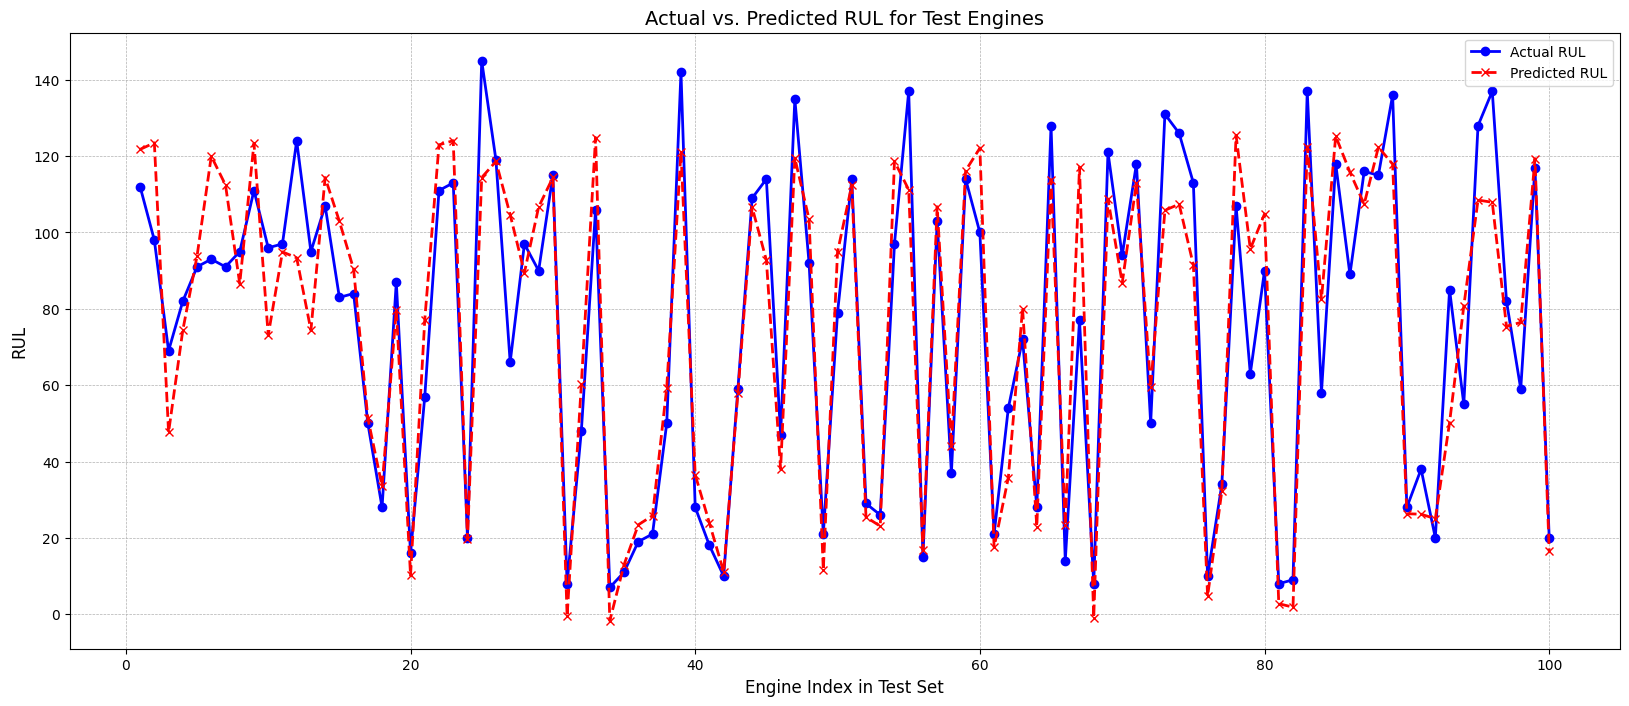

In [133]:
plt.figure(figsize=(20,8))

plt.plot(range(1,len(y_test_cycles)+1),y_test_cycles, label='Actual RUL', color='blue', marker='o', linestyle='-', linewidth=2, markersize=6)
plt.plot(range(1,len(y_pred_cycles)+1),y_pred_cycles, label='Predicted RUL', color='red', marker='x', linestyle='--', linewidth=2, markersize=6)

plt.title('Actual vs. Predicted RUL for Test Engines', fontsize=14)
plt.xlabel('Engine Index in Test Set', fontsize=12)
plt.ylabel('RUL', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

#### Keras Tuner

In [91]:
def Conv1d_LSTM_kt(hp):    
    tf.random.set_seed(42)
    np.random.seed(42)

    model = Sequential()
    model.add(Input(shape=(x_train_reshaped.shape[1],x_train_reshaped.shape[2])))

    num_hidden_layer = hp.Choice('num_hidden_layer', [1, 2])
    dropout_rate = hp.Choice('dropout_rate', [0.1,0.2])
    #batch_size = hp.Choice('batch_size', [64])

    model.add(Conv1D(filters=hp.Choice('n_f1', [128,64]), kernel_size=hp.Choice('k_s1',[5]), padding='same'))
    #model.add(BatchNormalization())
    model.add(ReLU())

    if num_hidden_layer == 2:
        n_f2 = hp.Choice('n_f2', [128,64])
        k_s2 = hp.Choice('k_s2',[5])
        model.add(Conv1D(filters=n_f2, kernel_size=k_s2, padding='same'))
        #model.add(BatchNormalization())
        model.add(ReLU())

    model.add(LSTM(units=hp.Choice('n_lstm1', [64 , 128]), return_sequences=True))
    #model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    if num_hidden_layer == 2:
        n_lstm2 = hp.Choice('n_lstm2', [128,64])
        model.add(LSTM(units=n_lstm2, return_sequences=True))
        #model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(GlobalAveragePooling1D())

    model.add(Dense(units=hp.Choice('n_l1', [50,100]), activation=None, 
                    kernel_regularizer=regularizers.L2(hp.Float('k_l2', 0, 0.11, step=0.1))))
    #model.add(BatchNormalization())
    model.add(ReLU())
    model.add(Dropout(dropout_rate))

    if num_hidden_layer == 2:
        n_l2 = hp.Choice('n_l2', [50,100])
        k_l2 = hp.Float('k_l2', 0, 0.11, step=0.1)
        model.add(Dense(units=n_l2, activation=None, 
                        kernel_regularizer=regularizers.L2(k_l2)))
        #model.add(BatchNormalization())
        model.add(ReLU())
        model.add(Dropout(dropout_rate))

    model.add(Dense(units=1))
    model.add(LeakyReLU())

    model.compile(optimizer=Adam(learning_rate=hp.Choice('learning_rate', values=[1e-3])), loss='mean_squared_error', metrics=['mse'])
    #RMSprop(learning_rate=lr, rho=0.9)
    return model

In [92]:
tuner = kt.Hyperband(hypermodel=Conv1d_LSTM_kt,
                     objective='val_mse',    
                     max_epochs=70,
                     factor=3,                
                     hyperband_iterations=1,  
                     directory='./tuner_logs',
                     project_name='conv1d_lstm_hb',
                     overwrite=True
)

In [93]:
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)

tuner.search(
    x_train_reshaped,
    y_train_reshaped,
    validation_split=0.15,
    verbose=2,
    epochs=70,
    batch_size=64,
    callbacks=[early_stop,reduce_lr]
)

Trial 90 Complete [00h 02m 42s]
val_mse: 0.013172750361263752

Best val_mse So Far: 0.011150415055453777
Total elapsed time: 01h 13m 31s
INFO:tensorflow:Oracle triggered exit


In [94]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
for key, value in best_hp.values.items():
    print(f'{key}: {value}')

num_hidden_layer: 2
dropout_rate: 0.1
n_f1: 128
k_s1: 5
n_lstm1: 128
n_l1: 100
k_l2: 0.0
learning_rate: 0.001
n_f2: 64
k_s2: 5
n_lstm2: 128
n_l2: 50
tuner/epochs: 70
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0


In [95]:
model = tuner.hypermodel.build(best_hp)
model.fit(x_train_reshaped, y_train_reshaped, epochs=70, batch_size=64, validation_split=0.15,callbacks=[early_stop,reduce_lr])

Epoch 1/70
236/236 [==============================] - 8s 23ms/step - loss: 0.0570 - mse: 0.0570 - val_loss: 0.0344 - val_mse: 0.0344 - lr: 0.0010
Epoch 2/70
236/236 [==============================] - 5s 20ms/step - loss: 0.0321 - mse: 0.0321 - val_loss: 0.0286 - val_mse: 0.0286 - lr: 0.0010
Epoch 3/70
236/236 [==============================] - 5s 20ms/step - loss: 0.0215 - mse: 0.0215 - val_loss: 0.0207 - val_mse: 0.0207 - lr: 0.0010
Epoch 4/70
236/236 [==============================] - 5s 20ms/step - loss: 0.0175 - mse: 0.0175 - val_loss: 0.0219 - val_mse: 0.0219 - lr: 0.0010
Epoch 5/70
236/236 [==============================] - 5s 20ms/step - loss: 0.0163 - mse: 0.0163 - val_loss: 0.0154 - val_mse: 0.0154 - lr: 0.0010
Epoch 6/70
236/236 [==============================] - 5s 20ms/step - loss: 0.0151 - mse: 0.0151 - val_loss: 0.0176 - val_mse: 0.0176 - lr: 0.0010
Epoch 7/70
236/236 [==============================] - 5s 20ms/step - loss: 0.0145 - mse: 0.0145 - val_loss: 0.0117 - val_mse

In [96]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_2 (Conv1D)           (None, 30, 128)           9088      
                                                                 
 re_lu_4 (ReLU)              (None, 30, 128)           0         
                                                                 
 conv1d_3 (Conv1D)           (None, 30, 64)            41024     
                                                                 
 re_lu_5 (ReLU)              (None, 30, 64)            0         
                                                                 
 lstm_2 (LSTM)               (None, 30, 128)           98816     
                                                                 
 dropout_4 (Dropout)         (None, 30, 128)           0         
                                                                 
 lstm_3 (LSTM)               (None, 30, 128)          

In [97]:
RUL_max = 125.0
RUL_min = 0.0

# Predict y_test and convert back to cycles
y_pred_norm_kt = model.predict(x_test_reshaped)
y_pred_cycles_kt = y_pred_norm_kt * (RUL_max - RUL_min) + RUL_min
y_test_cycles = y_test * (RUL_max - RUL_min) + RUL_min

# Compute RMSE in cycles
rmse_cycles = np.sqrt(mean_squared_error(y_test_cycles, y_pred_cycles_kt))
print(f'Test RMSE (cycles): {rmse_cycles:.2f}')

4/4 [==============================] - 1s 20ms/step
Test RMSE (cycles): 13.77


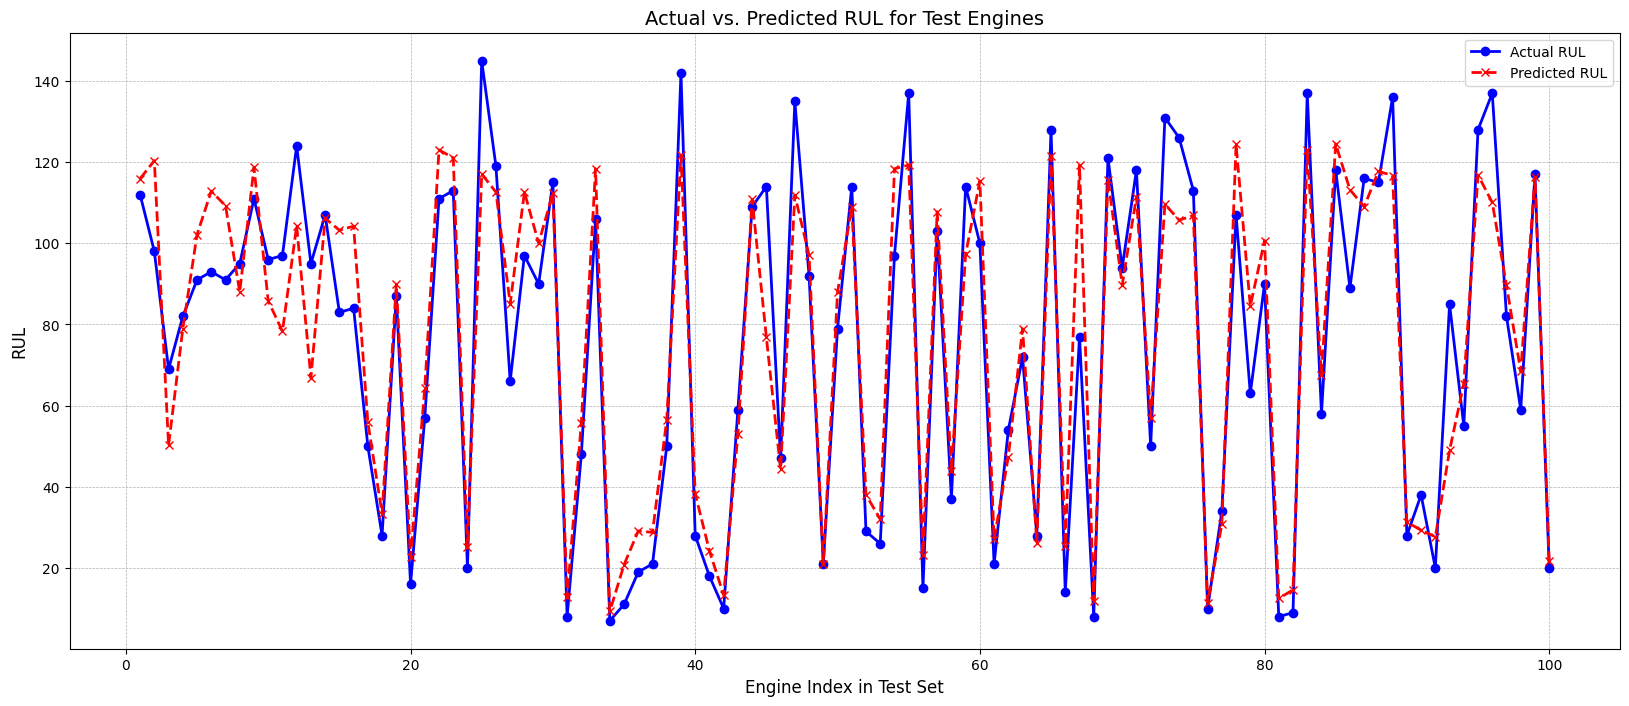

In [98]:
plt.figure(figsize=(20,8))

plt.plot(range(1,len(y_test_cycles)+1),y_test_cycles, label='Actual RUL', color='blue', marker='o', linestyle='-', linewidth=2, markersize=6)
plt.plot(range(1,len(y_pred_cycles_kt)+1),y_pred_cycles_kt, label='Predicted RUL', color='red', marker='x', linestyle='--', linewidth=2, markersize=6)

plt.title('Actual vs. Predicted RUL for Test Engines', fontsize=14)
plt.xlabel('Engine Index in Test Set', fontsize=12)
plt.ylabel('RUL', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

## (RFR Data) Selected Features Using Importance Calculated by Random Forest Regressor 

#### Keras Tuner

In [36]:
def Conv1d_LSTM_kt(hp):    
    tf.random.set_seed(42)
    np.random.seed(42)

    model = Sequential()
    model.add(Input(shape=(x_train_RFR_reshaped.shape[1],x_train_RFR_reshaped.shape[2])))

    num_hidden_layer = hp.Choice('num_hidden_layer', [1, 2])
    dropout_rate = hp.Choice('dropout_rate', [0.1,0.2])
    #batch_size = hp.Choice('batch_size', [64])

    model.add(Conv1D(filters=hp.Choice('n_f1', [128,64]), kernel_size=hp.Choice('k_s1',[5]), padding='same'))
    #model.add(BatchNormalization())
    model.add(ReLU())

    if num_hidden_layer == 2:
        n_f2 = hp.Choice('n_f2', [128,64])
        k_s2 = hp.Choice('k_s2',[5])
        model.add(Conv1D(filters=n_f2, kernel_size=k_s2, padding='same'))
        #model.add(BatchNormalization())
        model.add(ReLU())

    model.add(LSTM(units=hp.Choice('n_lstm1', [64 , 128]), return_sequences=True))
    #model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    if num_hidden_layer == 2:
        n_lstm2 = hp.Choice('n_lstm2', [128,64])
        model.add(LSTM(units=n_lstm2, return_sequences=True))
        #model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(GlobalAveragePooling1D())

    model.add(Dense(units=hp.Choice('n_l1', [50,100]), activation=None, 
                    kernel_regularizer=regularizers.L2(hp.Float('k_l2', 0, 0.11, step=0.1))))
    #model.add(BatchNormalization())
    model.add(ReLU())
    model.add(Dropout(dropout_rate))

    if num_hidden_layer == 2:
        n_l2 = hp.Choice('n_l2', [50,100])
        k_l2 = hp.Float('k_l2', 0, 0.11, step=0.1)
        model.add(Dense(units=n_l2, activation=None, 
                        kernel_regularizer=regularizers.L2(k_l2)))
        #model.add(BatchNormalization())
        model.add(ReLU())
        model.add(Dropout(dropout_rate))

    model.add(Dense(units=1))
    model.add(LeakyReLU())

    model.compile(optimizer=Adam(learning_rate=hp.Choice('learning_rate', values=[1e-3])), loss='mean_squared_error', metrics=['mse'])
    #RMSprop(learning_rate=lr, rho=0.9)
    return model

In [37]:
tuner_RFR = kt.Hyperband(hypermodel=Conv1d_LSTM_kt,
                     objective='val_mse',    
                     max_epochs=70,
                     factor=3,                
                     hyperband_iterations=1,  
                     directory='./tuner_logs',
                     project_name='conv1d_lstm_hb_RFRDATA',
                     overwrite=True
)

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)

tuner_RFR.search(
    x_train_RFR_reshaped,
    y_train_reshaped,
    validation_split=0.15,
    verbose=2,
    epochs=70,
    batch_size=64,
    callbacks=[early_stop,reduce_lr]
)

Trial 90 Complete [00h 02m 11s]
val_mse: 0.01344920601695776

Best val_mse So Far: 0.012507322244346142
Total elapsed time: 01h 18m 10s
INFO:tensorflow:Oracle triggered exit


In [38]:
best_hp = tuner_RFR.get_best_hyperparameters(num_trials=1)[0]
for key, value in best_hp.values.items():
    print(f'{key}: {value}')

num_hidden_layer: 2
dropout_rate: 0.1
n_f1: 64
k_s1: 5
n_lstm1: 64
n_l1: 100
k_l2: 0.0
learning_rate: 0.001
n_f2: 128
k_s2: 5
n_lstm2: 64
n_l2: 50
tuner/epochs: 70
tuner/initial_epoch: 24
tuner/bracket: 3
tuner/round: 3
tuner/trial_id: f519b088419c1bfb568a3957c42386cf


In [39]:
model_RFR = tuner_RFR.hypermodel.build(best_hp)
model_RFR.fit(x_train_RFR_reshaped, y_train_reshaped, epochs=70, batch_size=64, validation_split=0.15,callbacks=[early_stop,reduce_lr])

Epoch 1/70
236/236 [==============================] - 8s 23ms/step - loss: 0.0508 - mse: 0.0508 - val_loss: 0.0291 - val_mse: 0.0291 - lr: 0.0010
Epoch 2/70
236/236 [==============================] - 4s 18ms/step - loss: 0.0262 - mse: 0.0262 - val_loss: 0.0258 - val_mse: 0.0258 - lr: 0.0010
Epoch 3/70
236/236 [==============================] - 4s 19ms/step - loss: 0.0191 - mse: 0.0191 - val_loss: 0.0170 - val_mse: 0.0170 - lr: 0.0010
Epoch 4/70
236/236 [==============================] - 5s 19ms/step - loss: 0.0172 - mse: 0.0172 - val_loss: 0.0282 - val_mse: 0.0282 - lr: 0.0010
Epoch 5/70
236/236 [==============================] - 5s 19ms/step - loss: 0.0160 - mse: 0.0160 - val_loss: 0.0232 - val_mse: 0.0232 - lr: 0.0010
Epoch 6/70
236/236 [==============================] - 5s 19ms/step - loss: 0.0157 - mse: 0.0157 - val_loss: 0.0173 - val_mse: 0.0173 - lr: 0.0010
Epoch 7/70
236/236 [==============================] - 4s 19ms/step - loss: 0.0155 - mse: 0.0155 - val_loss: 0.0140 - val_mse

In [40]:
model_RFR.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_1 (Conv1D)           (None, 30, 64)            2624      
                                                                 
 re_lu_2 (ReLU)              (None, 30, 64)            0         
                                                                 
 conv1d_2 (Conv1D)           (None, 30, 128)           41088     
                                                                 
 re_lu_3 (ReLU)              (None, 30, 128)           0         
                                                                 
 lstm_1 (LSTM)               (None, 30, 64)            49408     
                                                                 
 dropout_2 (Dropout)         (None, 30, 64)            0         
                                                                 
 lstm_2 (LSTM)               (None, 30, 64)           

In [41]:
RUL_max = 125.0
RUL_min = 0.0

# Predict y_test and convert back to cycles
y_pred_norm_kt_RFR = model_RFR.predict(x_test_RFR_reshaped)
y_pred_cycles_kt_RFR = y_pred_norm_kt_RFR * (RUL_max - RUL_min) + RUL_min
y_test_cycles = y_test * (RUL_max - RUL_min) + RUL_min

# Compute RMSE in cycles
rmse_cycles = np.sqrt(mean_squared_error(y_test_cycles, y_pred_cycles_kt_RFR))
print(f'Test RMSE (cycles): {rmse_cycles:.2f}')

4/4 [==============================] - 1s 26ms/step
Test RMSE (cycles): 14.80


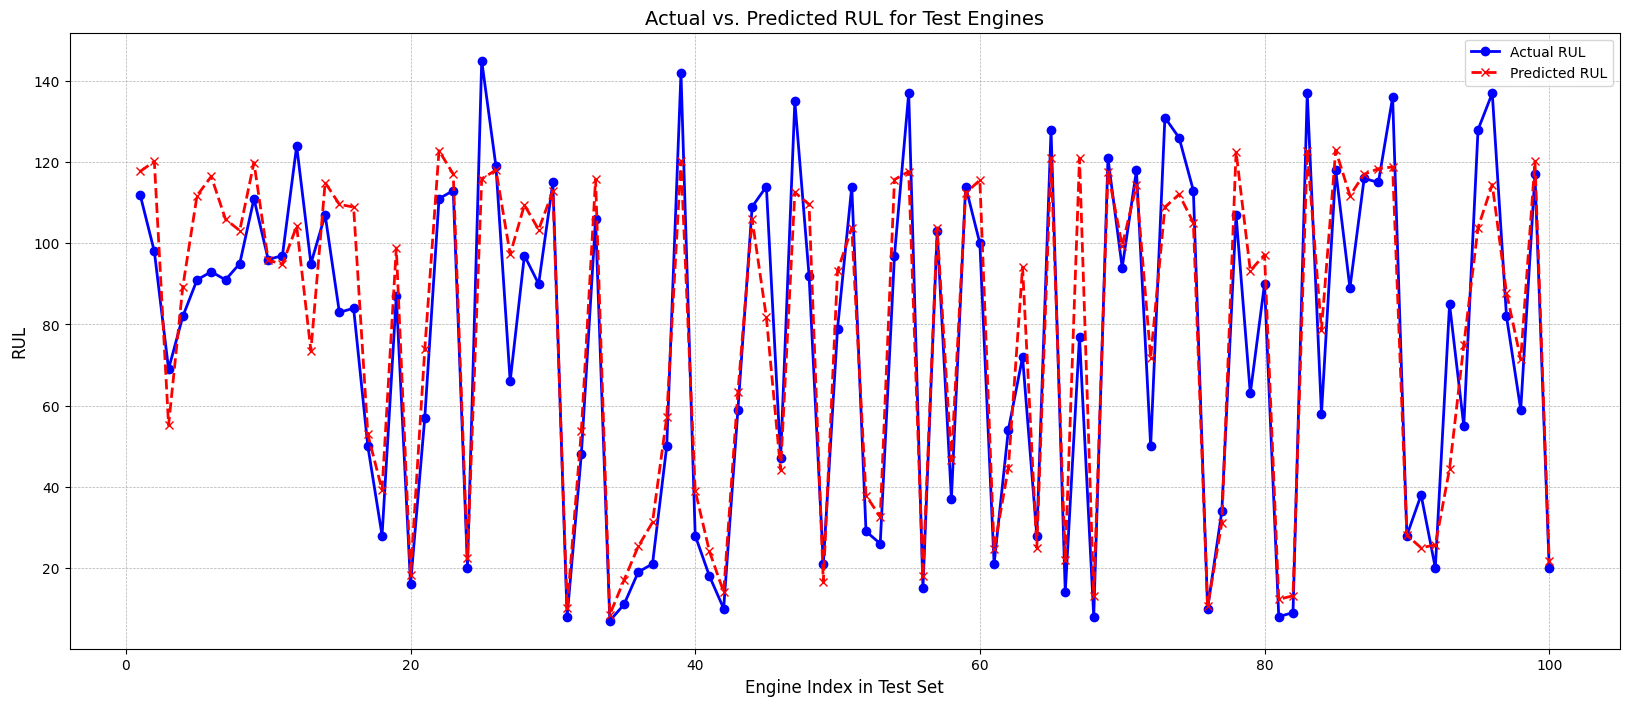

In [42]:
plt.figure(figsize=(20,8))

plt.plot(range(1,len(y_test_cycles)+1),y_test_cycles, label='Actual RUL', color='blue', marker='o', linestyle='-', linewidth=2, markersize=6)
plt.plot(range(1,len(y_pred_cycles_kt_RFR)+1),y_pred_cycles_kt_RFR, label='Predicted RUL', color='red', marker='x', linestyle='--', linewidth=2, markersize=6)

plt.title('Actual vs. Predicted RUL for Test Engines', fontsize=14)
plt.xlabel('Engine Index in Test Set', fontsize=12)
plt.ylabel('RUL', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()